# Clasificación multiclase

## Introduction

En este ejercicio se implementa la regresion one-vs-all
Antes de empezar la ejecución de las partes de codigo correspondienters a los ejercicios, se requiere importar todas las librerias necesarias.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Drive conectado.")

Mounted at /content/drive
Drive conectado.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

print("Librerías cargadas.")

Librerías cargadas.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

print("Métricas listas.")

Métricas listas.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

Dispositivo: cuda


In [ ]:
path = '/content/drive/MyDrive/colab/lab6/'

X_train = pd.read_csv(path + 'Copia de Copia de csvTrainImages 60k x 784.csv', header=None)
y_train = pd.read_csv(path + 'Copia de Copia de csvTrainLabel 60k x 1.csv', header=None)

X_test = pd.read_csv(path + 'Copia de Copia de csvTestImages 10k x 784.csv', header=None)
y_test = pd.read_csv(path + 'Copia de Copia de csvTestLabel 10k x 1.csv', header=None)

print("Dataset cargado.")

Dataset cargado.


In [ ]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy().ravel()

X_test = X_test.to_numpy()
y_test = y_test.to_numpy().ravel()

print("Datos convertidos a numpy.")

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Datos convertidos a numpy.
Train: (60000, 784)
Test: (10000, 784)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Datos normalizados.")

Datos normalizados.


In [ ]:
arabic_digits = {
0:'٠',1:'١',2:'٢',3:'٣',4:'٤',
5:'٥',6:'٦',7:'٧',8:'٨',9:'٩'
}

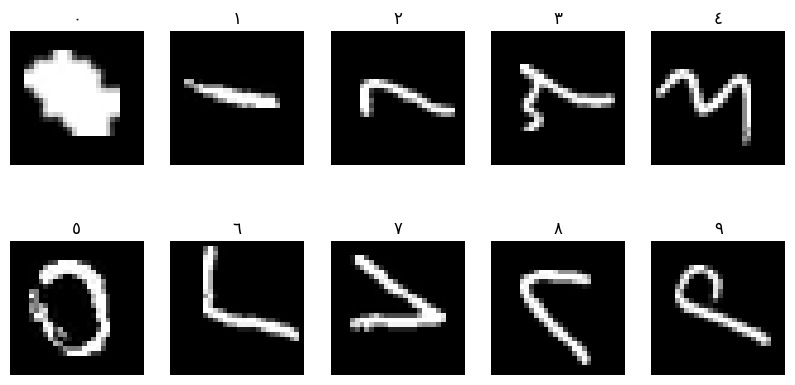

Visualización lista.


In [ ]:
fig, axs = plt.subplots(2,5, figsize=(10,5))

for i in range(10):

    img = X_train[i].reshape(28,28)

    axs[i//5, i%5].imshow(img, cmap='gray')

    axs[i//5, i%5].set_title(arabic_digits[y_train[i]])

    axs[i//5, i%5].axis("off")

plt.show()

print("Visualización lista.")

In [ ]:
class ArabicDigitsDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).long()

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [ ]:
train_dataset = ArabicDigitsDataset(X_train, y_train)
test_dataset = ArabicDigitsDataset(X_test, y_test)

print("Datasets creados.")

Datasets creados.


In [ ]:
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoader listo.")

DataLoader listo.


In [ ]:
class MultiClassNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(784,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,10)
        )

    def forward(self,x):

        return self.net(x)

In [ ]:
model = MultiClassNN().to(device)

print("Modelo creado.")
print(model)

Modelo creado.
MultiClassNN(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss y optimizer listos.")

Loss y optimizer listos.


In [ ]:
train_losses = []
train_accuracies = []

print("Listas métricas listas.")

Listas métricas listas.


In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y_batch).sum().item()

        total += y_batch.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print("Epoch:", epoch+1)
    print("Loss:", epoch_loss)
    print("Accuracy:", epoch_acc)

Epoch: 1
Loss: 0.30389339508528407
Accuracy: 0.9262833333333333
Epoch: 2
Loss: 0.09259075829957394
Accuracy: 0.9748333333333333
Epoch: 3
Loss: 0.0641275896274663
Accuracy: 0.98245
Epoch: 4
Loss: 0.0467944444890352
Accuracy: 0.9869166666666667
Epoch: 5
Loss: 0.03549287880552893
Accuracy: 0.99005
Epoch: 6
Loss: 0.025928101192248313
Accuracy: 0.9929333333333333
Epoch: 7
Loss: 0.021581433358740933
Accuracy: 0.9939
Epoch: 8
Loss: 0.015860880418938208
Accuracy: 0.9955333333333334
Epoch: 9
Loss: 0.013138170056342286
Accuracy: 0.9964333333333333
Epoch: 10
Loss: 0.011336999874997963
Accuracy: 0.9969


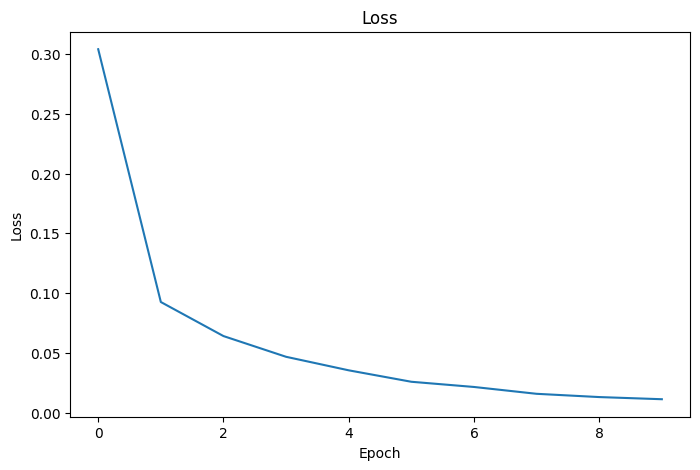

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

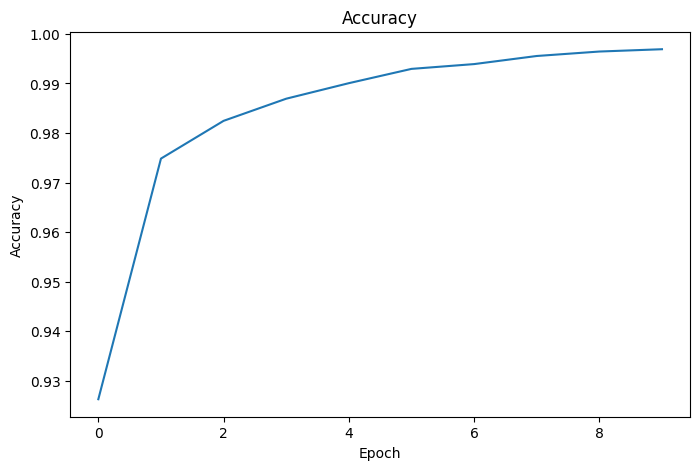

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies)

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

1. ACCURACY
Qué es

Accuracy = porcentaje de predicciones correctas.

Mide qué tan bien el modelo clasifica en general.

Para qué sirve

Sirve para saber rendimiento general del modelo.

Si accuracy = 0.97

→ el modelo acierta 97% de las veces.

Pero tiene problema:

⚠️ No muestra dónde se equivoca.

Por eso se usan otras métricas.



In [ ]:
all_preds = []
all_labels = []
all_probs = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

print("Predicciones guardadas.")

Predicciones guardadas.


In [ ]:
acc = accuracy_score(all_labels, all_preds)

print("ACCURACY FINAL")
print(acc*100,"%")

ACCURACY FINAL
98.13 %


2. MATRIZ DE CONFUSIÓN
Qué es

La Matriz de Confusión muestra:

qué clases el modelo acierta
qué clases el modelo confunde

Para clasificación multiclase (0-9) se crea matriz 10×10.

Para qué sirve

Sirve para ver:

qué números el modelo reconoce bien
qué números confunde

Ejemplo típico MNIST:

5 se confunde con 3
9 se confunde con 4

Matriz de Confusión:
[[950  13   1   1   1  18   3   3   5   5]
 [  4 986   0   0   5   0   2   0   1   2]
 [  7   0 981   1   9   2   0   0   0   0]
 [  0   1  16 969   2   1   6   2   1   2]
 [  0   2   7   1 981   4   1   0   0   4]
 [  6   0   4   0   3 980   1   3   0   3]
 [  0   1   0   0   1   0 994   0   0   4]
 [  1   0   0   0   0   1   2 995   0   1]
 [  1   0   1   0   0   1   0   0 991   6]
 [  0   1   5   1   1   1   4   0   1 986]]


<Figure size 800x600 with 0 Axes>

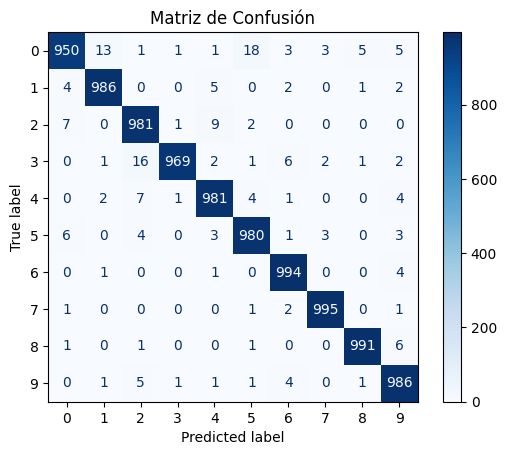

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

print("Matriz de Confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(8,6))

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")

plt.show()

3. PRECISION, RECALL Y F1 SCORE

Estas métricas se basan en la matriz de confusión.

Primero definimos conceptos.

Precision

Precision mide:

cuando el modelo predice una clase, qué tan seguido tiene razón

Recall

Recall mide:

de todos los casos reales, cuántos detectó el modelo

F1 Score

F1 combina precision y recall.
Para qué sirve

F1 es mejor métrica cuando:

dataset desbalanceado
queremos equilibrio entre errores

En ML real F1 es muy usada.

In [ ]:
precision = precision_score(all_labels, all_preds, average="macro")

recall = recall_score(all_labels, all_preds, average="macro")

f1 = f1_score(all_labels, all_preds, average="macro")

print("PRECISION:",precision)
print("RECALL:",recall)
print("F1 SCORE:",f1)

PRECISION: 0.9813749606934434
RECALL: 0.9813000000000001
F1 SCORE: 0.9812791473955951


In [ ]:
classes = np.unique(all_labels)

y_bin = label_binarize(all_labels, classes=classes)

print("Clases binarizadas:", y_bin.shape)

Clases binarizadas: (10000, 10)


Cómo se ve la ROC

Gráfica:

X → FPR
Y → TPR

Modelo perfecto:

sube rápido a la esquina superior izquierda.

Modelo aleatorio:

línea diagonal.

Para qué sirve

Sirve para:

evaluar clasificadores
ver capacidad de separación

Mientras más cerca de arriba → mejor modelo.

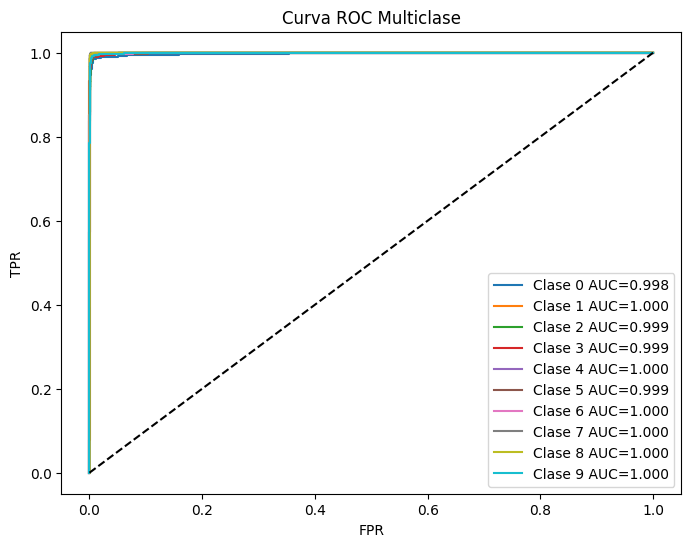

In [ ]:
plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])

    auc = roc_auc_score(y_bin[:,i], all_probs[:,i])

    plt.plot(fpr, tpr, label=f"Clase {i} AUC={auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("Curva ROC Multiclase")

plt.legend()

plt.show()

5. ROC AUC

ROC AUC = área bajo la curva ROC.

Valores:

Valor	     Significado
0.5	     modelo aleatorio
0.7	     modelo aceptable
0.8	     modelo bueno
0.9	     modelo excelente
1.0	     perfecto

In [ ]:
roc_auc = roc_auc_score(y_bin, all_probs, average="macro", multi_class="ovr")

print("ROC AUC GLOBAL:", roc_auc)

ROC AUC GLOBAL: 0.9994381611111113


In [ ]:
from PIL import Image

PREDICCIÓN DE imagen.png
Clase predicha: 4
Dígito árabe: ٤


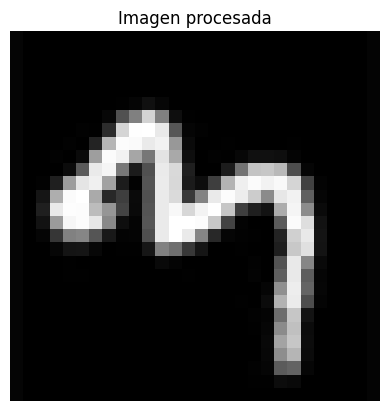

In [ ]:
from PIL import Image

img_path = '/content/drive/MyDrive/colab/lab5/imagen.png'

img = Image.open(img_path)

img = img.convert('L')

img = img.resize((28,28))

img_arr = np.array(img)

img_arr = img_arr / 255.0

plt.imshow(img_arr, cmap='gray')

plt.title("Imagen procesada")

plt.axis("off")

plt.show()

In [ ]:
img_vec = img_arr.reshape(1,784)

img_tensor = torch.tensor(img_vec).float().to(device)

print("Shape:", img_tensor.shape)

Shape: torch.Size([1, 784])


In [ ]:
model.eval()

with torch.no_grad():

    output = model(img_tensor)

    pred = torch.argmax(output, dim=1).item()

print("Clase predicha:", pred)

print("Dígito árabe:", arabic_digits[pred])

Clase predicha: 4
Dígito árabe: ٤


In [ ]:
plt.imshow(img_arr, cmap='gray')

plt.title(f"Predicción: {arabic_digits[pred]}")

plt.axis("off")

plt.show()